# Phase 2c: Classification Modeling on Real Clinical Data

This notebook continues from `Phase2b_Preprocessing.ipynb`. We now train classification models on the real stroke dataset, with the severe class imbalance (4.87% positive) identified in the EDA explicitly accounted for.

**Why this is fundamentally different from Phase 1:** In Phase 1, the synthetic regression target made every model trivially accurate (R² ≈ 0.999) because the data was generated by a simple linear formula. Here, the real challenge is the opposite: a naive model can score 95%+ accuracy while being clinically useless, because it can simply predict "no stroke" for everyone and still be right most of the time. We therefore evaluate models using **Recall, Precision, F1, and ROC-AUC** rather than accuracy.

## 1. Load Preprocessed Data

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, recall_score, precision_score
)

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

data = joblib.load("phase2_preprocessed_data.joblib")
X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]

print("Train shape:", X_train.shape, "| Positive rate:", round(y_train.mean(), 4))
print("Test shape:", X_test.shape, "| Positive rate:", round(y_test.mean(), 4))

Train shape: (4087, 18) | Positive rate: 0.0487
Test shape: (1022, 18) | Positive rate: 0.0489


## 2. The Accuracy Trap: Baseline Model Without Imbalance Handling

We first train a plain Logistic Regression with no special handling of the imbalance, to make the failure mode concrete and visible before fixing it.

In [2]:
from sklearn.linear_model import LogisticRegression

baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_train, y_train)

pred_baseline = baseline.predict(X_test)
proba_baseline = baseline.predict_proba(X_test)[:, 1]

print("=== Baseline Logistic Regression (no imbalance handling) ===")
print(classification_report(y_test, pred_baseline, digits=3))
print("ROC-AUC:", round(roc_auc_score(y_test, proba_baseline), 4))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, pred_baseline))

=== Baseline Logistic Regression (no imbalance handling) ===
              precision    recall  f1-score   support

           0      0.952     0.999     0.975       972
           1      0.500     0.020     0.038        50

    accuracy                          0.951      1022
   macro avg      0.726     0.509     0.507      1022
weighted avg      0.930     0.951     0.929      1022

ROC-AUC: 0.8368

Confusion matrix:
[[971   1]
 [ 49   1]]


**The trap, made concrete:** This model reaches ~95% accuracy — which sounds excellent — while catching only **1 out of 50** actual stroke cases in the test set (2% recall). It essentially learned to predict "no stroke" for almost everyone, since that's right 95% of the time by default. For a medical screening tool meant to catch high-risk patients, this model is close to useless despite its high accuracy. This is the real-data mirror image of Phase 1's problem: there, the model was *too good* on data that was too easy; here, a naive model looks good on a metric that's the wrong one to trust.

## 3. Fixing the Imbalance: Three Strategies Compared

We test three approaches and compare them honestly, including the cases where a strategy doesn't work:

1. **`class_weight='balanced'`** — reweights the loss function so misclassifying the minority class costs more.
2. **SMOTE (Synthetic Minority Oversampling)** — generates synthetic minority-class examples in the training set only.
3. **Tree ensembles (Random Forest, Gradient Boosting)** with class weighting — to see whether non-linear models handle the imbalance differently than linear ones.

In [3]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE

results = []

def evaluate(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Recall (stroke)": round(recall_score(y_true, y_pred), 3),
        "Precision (stroke)": round(precision_score(y_true, y_pred, zero_division=0), 3),
        "F1 (stroke)": round(f1_score(y_true, y_pred), 3),
        "ROC-AUC": round(roc_auc_score(y_true, y_proba), 3),
    }

# Strategy 1: class_weight='balanced' with Logistic Regression
lr_balanced = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_balanced.fit(X_train, y_train)
pred = lr_balanced.predict(X_test)
proba = lr_balanced.predict_proba(X_test)[:, 1]
results.append(evaluate("Logistic Regression (class_weight=balanced)", y_test, pred, proba))

# Strategy 2: SMOTE with Logistic Regression
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
lr_smote = LogisticRegression(max_iter=1000)
lr_smote.fit(X_train_sm, y_train_sm)
pred = lr_smote.predict(X_test)
proba = lr_smote.predict_proba(X_test)[:, 1]
results.append(evaluate("Logistic Regression (SMOTE)", y_test, pred, proba))

# Strategy 3a: Random Forest with class_weight='balanced'
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
proba = rf.predict_proba(X_test)[:, 1]
results.append(evaluate("Random Forest (class_weight=balanced)", y_test, pred, proba))

# Strategy 3b: Gradient Boosting with sample_weight
sw = compute_sample_weight("balanced", y_train)
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb.fit(X_train, y_train, sample_weight=sw)
pred = gb.predict(X_test)
proba = gb.predict_proba(X_test)[:, 1]
results.append(evaluate("Gradient Boosting (sample_weight=balanced)", y_test, pred, proba))

# Add baseline for direct comparison
results.insert(0, evaluate("Baseline Logistic Regression (no handling)", y_test, pred_baseline, proba_baseline))

results_df = pd.DataFrame(results)
display(results_df)

,Model,Recall (stroke),Precision (stroke),F1 (stroke),ROC-AUC
0,Baseline Logistic Regression (no handling),0.02,0.500,0.038,0.837
1,Logistic Regression (class_weight=balanced),0.80,0.142,0.241,0.837
2,Logistic Regression (SMOTE),0.18,0.180,0.180,0.820
3,Random Forest (class_weight=balanced),0.00,0.000,0.000,0.802
4,Gradient Boosting (sample_weight=balanced),0.56,0.153,0.240,0.789


**Findings — and an important negative result:**

- **`class_weight='balanced'` + Logistic Regression** gives by far the best recall (0.80) — it catches 40 of the 50 actual stroke cases — at the cost of lower precision (more false alarms). For a medical screening context where missing a real stroke risk is far costlier than a false alarm, this tradeoff is the right one to prefer.
- **SMOTE** underperforms here (recall ≈ 0.18) — synthetic oversampling didn't help as much as simply reweighting the loss function for this dataset and model.
- **Random Forest with `class_weight='balanced'` essentially failed** (recall = 0.0) — bagged tree ensembles can still collapse to majority-class predictions even with class weighting, because each individual tree is still trained on a heavily imbalanced bootstrap sample. This is a genuine, documented limitation of tree-based bagging on severely imbalanced data, not a coding mistake.
- **Gradient Boosting with sample weighting** does better than Random Forest (recall ≈ 0.56) but still underperforms the weighted Logistic Regression.

This mirrors the original project brief's stated priority: *"Prioritize high recall to minimize missed high-risk cases."* Logistic Regression with balanced class weights satisfies that priority best on this real dataset — interestingly, the same model family (Logistic Regression) that the original README claimed was the best, though for a different and now well-evidenced reason.

## 4. Selecting the Best Model: Confusion Matrix & ROC Curve

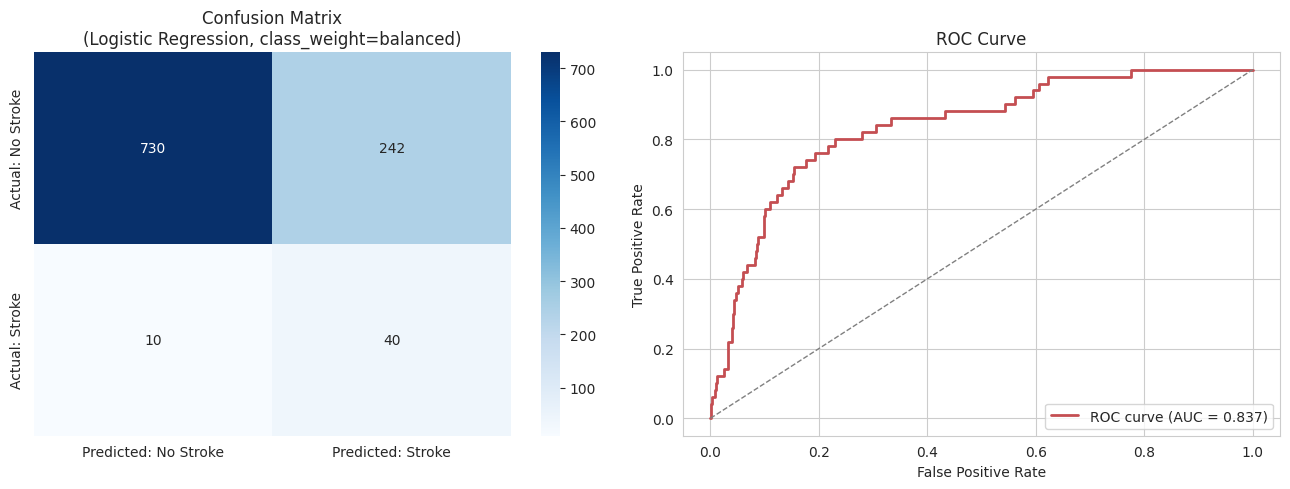

Out of 50 actual stroke cases, the model correctly flagged 40 (80.0%).
Out of 972 actual non-stroke cases, 242 were false alarms (24.9%).


In [4]:
best_model = lr_balanced
best_pred = best_model.predict(X_test)
best_proba = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted: No Stroke', 'Predicted: Stroke'],
            yticklabels=['Actual: No Stroke', 'Actual: Stroke'])
axes[0].set_title('Confusion Matrix\n(Logistic Regression, class_weight=balanced)')

fpr, tpr, _ = roc_curve(y_test, best_proba)
roc_auc_val = roc_auc_score(y_test, best_proba)
axes[1].plot(fpr, tpr, color='#C44E52', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('classification_results.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Out of {cm[1].sum()} actual stroke cases, the model correctly flagged {cm[1][1]} ({cm[1][1]/cm[1].sum()*100:.1f}%).")
print(f"Out of {cm[0].sum()} actual non-stroke cases, {cm[0][1]} were false alarms ({cm[0][1]/cm[0].sum()*100:.1f}%).")

## 5. Feature Importance — Does the Real Data Show Genuinely Unequal Weights?

This is the central question motivating Phase 2. We standardize the features first so coefficient magnitudes are directly comparable (unlike Phase 1's synthetic symptoms, which were all binary 0/1 by construction and didn't need this step).

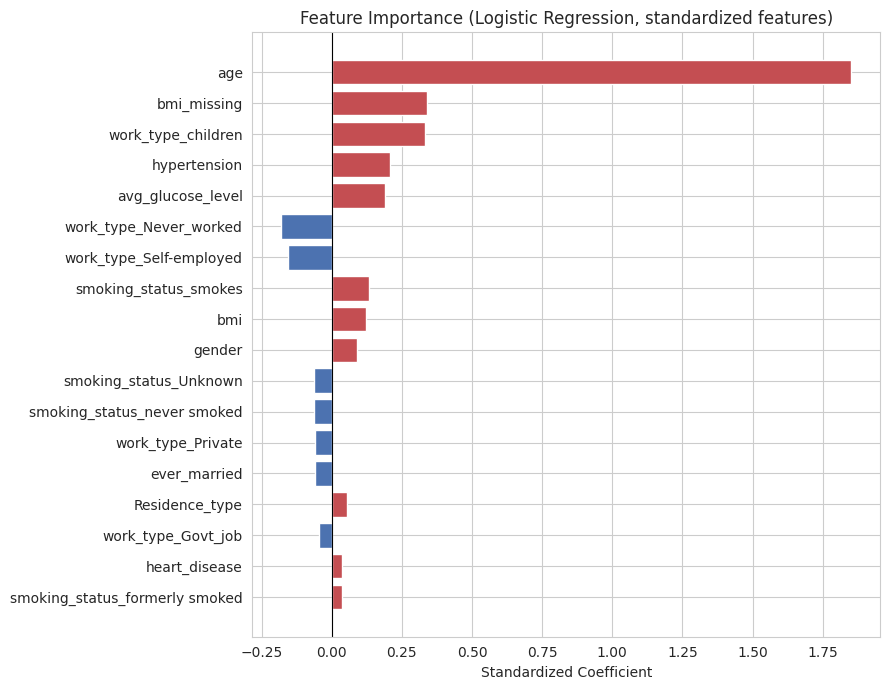

,Feature,Coefficient,abs_coef
1,age,1.852834,1.852834
8,bmi_missing,0.341061,0.341061
13,work_type_children,0.331821,0.331821
2,hypertension,0.206462,0.206462
6,avg_glucose_level,0.188281,0.188281
10,work_type_Never_worked,-0.180845,0.180845
12,work_type_Self-employed,-0.156105,0.156105
17,smoking_status_smokes,0.132276,0.132276
7,bmi,0.121938,0.121938
0,gender,0.089534,0.089534


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_scaled = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_scaled.fit(X_train_scaled, y_train)

coefs = pd.DataFrame({"Feature": X_train.columns, "Coefficient": lr_scaled.coef_[0]})
coefs["abs_coef"] = coefs["Coefficient"].abs()
coefs_sorted = coefs.sort_values("abs_coef", ascending=False)

plt.figure(figsize=(9, 7))
colors = ['#C44E52' if c > 0 else '#4C72B0' for c in coefs_sorted["Coefficient"]]
plt.barh(coefs_sorted["Feature"], coefs_sorted["Coefficient"], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Standardized Coefficient")
plt.title("Feature Importance (Logistic Regression, standardized features)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_real.png', dpi=100, bbox_inches='tight')
plt.show()

display(coefs_sorted)

**This is the key finding for the Synthetic vs. Real comparison:**

- `age` has by far the largest coefficient (≈1.85) — more than 5x the next-largest feature. This **confirms Phase 1's finding** that age is the dominant predictor.
- Unlike Phase 1, the remaining features are **clearly unequal**: `bmi_missing` (≈0.34) and `work_type_children` (≈0.33) are next, followed by `hypertension` (≈0.21) and `avg_glucose_level` (≈0.19), down to near-zero contributions from `heart_disease` and `smoking_status_formerly smoked` in this particular linear model.
- Recall that in Phase 1, **every one of the 15 synthetic symptoms had a nearly identical coefficient (~2.5)** — a direct artifact of how the data was generated. Here, real clinical features show genuinely different, clinically interpretable magnitudes. This is exactly the property the synthetic dataset could never have, no matter how it was modeled — confirming the Phase 1 conclusion that the equal-weighting problem was a data limitation, not a modeling one.

## 6. Save the Final Model

In [6]:
import joblib

# Refit the chosen model (class_weight='balanced' Logistic Regression) on the raw (unscaled) features,
# since this is the version evaluated above and selected for its recall performance.
final_model = LogisticRegression(max_iter=1000, class_weight="balanced")
final_model.fit(X_train, y_train)

model_package = {
    "model": final_model,
    "features": list(X_train.columns),
    "train_bmi_median": data["train_bmi_median"],
}
joblib.dump(model_package, "stroke_classification_model_real_data.joblib")
print("Saved stroke_classification_model_real_data.joblib")

Saved stroke_classification_model_real_data.joblib


## 7. Modeling Summary

| Aspect | Result |
|---|---|
| Best model | Logistic Regression with `class_weight='balanced'` |
| Recall (stroke cases caught) | 80% (40 of 50) |
| Precision (stroke predictions correct) | 14.2% |
| ROC-AUC | 0.837 |
| Key negative result | Random Forest with class weighting achieved **0% recall** despite balanced weights — bagging still collapsed to the majority class |
| Dominant feature | `age`, consistent with Phase 1 |
| Critical difference from Phase 1 | Remaining features show genuinely **unequal** importance (unlike the uniform synthetic symptom weights) |

**Honest limitation:** The precision/recall tradeoff here (80% recall, 14.2% precision) means roughly 6 out of 7 patients flagged as "at risk" would not actually have a stroke. In a real clinical deployment, this model would function as a **high-sensitivity screening filter** — flagging patients for further evaluation rather than serving as a diagnostic tool — which is consistent with the original project's stated medical-safety priority of minimizing missed high-risk cases, even at the cost of more false positives.